In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [41]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

In [4]:
dataset_path = "/content/drive/MyDrive/face_analysis/Datasets"

In [5]:
# Image Parameters
img_height = 224
img_width = 224
batch_size = 32

# Load Training Dataset
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Load Validation Dataset
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Display Class Names
class_names = train_dataset.class_names

print("Classes:")
print(class_names)

Found 1803 files belonging to 6 classes.
Using 1443 files for training.
Found 1803 files belonging to 6 classes.
Using 360 files for validation.
Classes:
['acne', 'blackheads', 'clear skin', 'dark spots', 'puffy eyes', 'wrinkles']


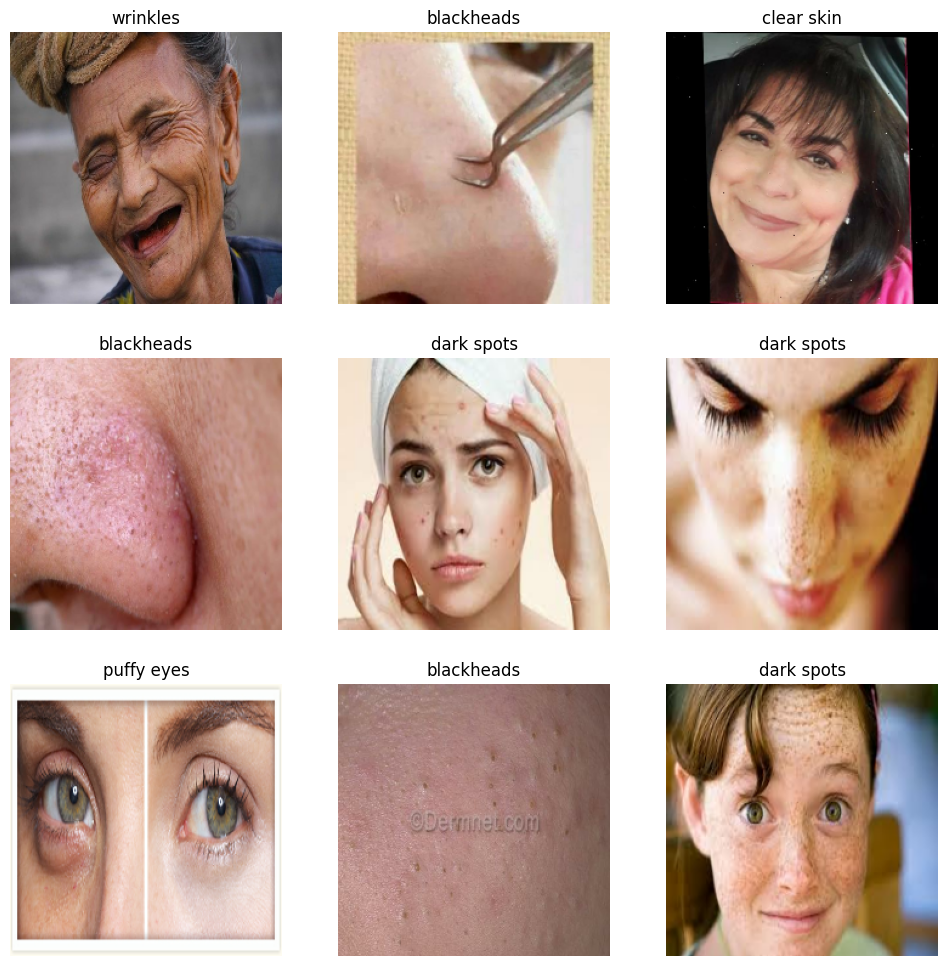

In [6]:
# Display Sample Images

plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [7]:
# Optimize Dataset Performance

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

In [8]:
# Load Pre-trained MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base model
base_model.trainable = False

# Build the complete model
model = Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation="softmax")
])

# Display model summary
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Compile the Model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
# Early Stopping Callback This prevents overfitting by stopping training if the validation accuracy stops improving

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [12]:
# Train the Model

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 315s 7s/step - accuracy: 0.5336 - loss: 1.2041 - val_accuracy: 0.7222 - val_loss: 0.8092
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.7471 - loss: 0.7016 - val_accuracy: 0.7694 - val_loss: 0.6795
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8018 - loss: 0.5680 - val_accuracy: 0.7972 - val_loss: 0.6179
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.8323 - loss: 0.4971 - val_accuracy: 0.8139 - val_loss: 0.5818
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8517 - loss: 0.4480 - val_accuracy: 0.8028 - val_loss: 0.5549
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8621 - loss: 0.3966 - val_accuracy: 0.8028 - val_loss: 0.5617
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.8711 - loss: 0.3704 - val_accuracy: 0.8028 - val_loss: 0.5434
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.8870 - loss: 0.3582 - val_accuracy: 0.8028 - val_

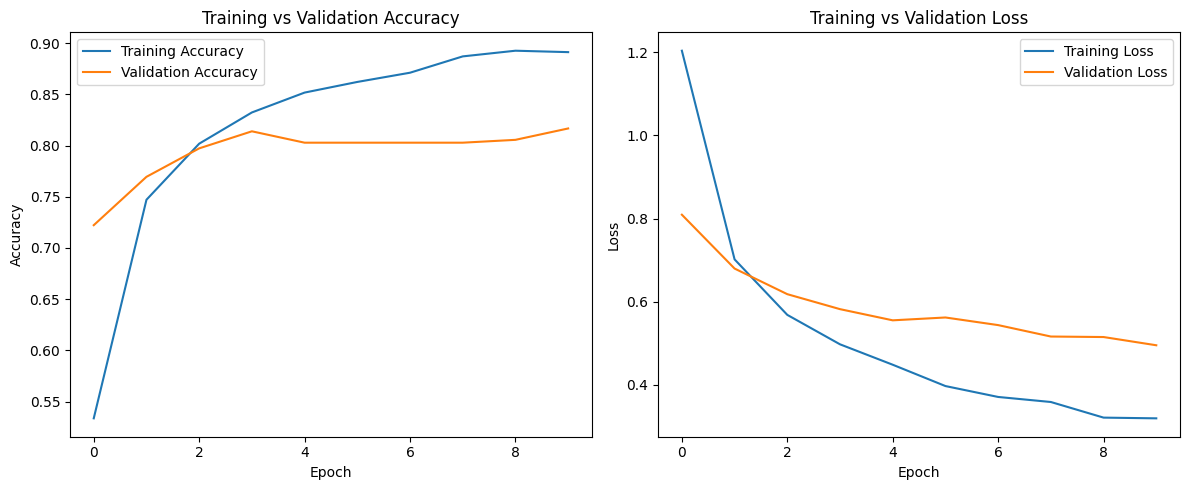

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
print("Evaluating model...")

loss, accuracy = model.evaluate(validation_dataset)

print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

Evaluating model...
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.8167 - loss: 0.4948

Validation Loss: 0.4948
Validation Accuracy: 0.8167


In [15]:
# Save the trained model

model.save("/content/drive/MyDrive/face_analysis/facial_skin_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [39]:
from google.colab import files

uploaded = files.upload()

Saving clear_skin_002.jpg to clear_skin_002.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


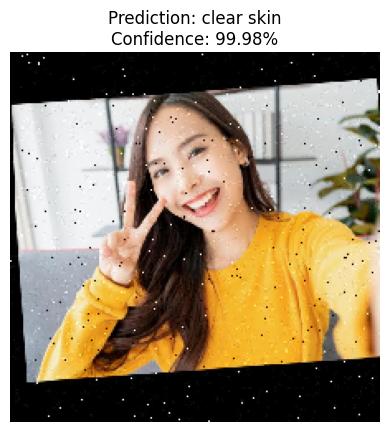

Predicted Skin Condition: clear skin
Confidence: 99.98%


In [40]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Get uploaded file name
img_path = list(uploaded.keys())[0]

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)


prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print(f"Predicted Skin Condition: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

In [42]:
# Generate predictions on validation dataset

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [43]:
print("Classification Report\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

Classification Report

              precision    recall  f1-score   support

        acne       0.76      0.82      0.79        57
  blackheads       0.77      0.73      0.75        49
  clear skin       0.91      0.94      0.92        63
  dark spots       0.79      0.81      0.80        57
  puffy eyes       0.82      0.81      0.81        67
    wrinkles       0.84      0.78      0.81        67

    accuracy                           0.82       360
   macro avg       0.81      0.81      0.81       360
weighted avg       0.82      0.82      0.82       360



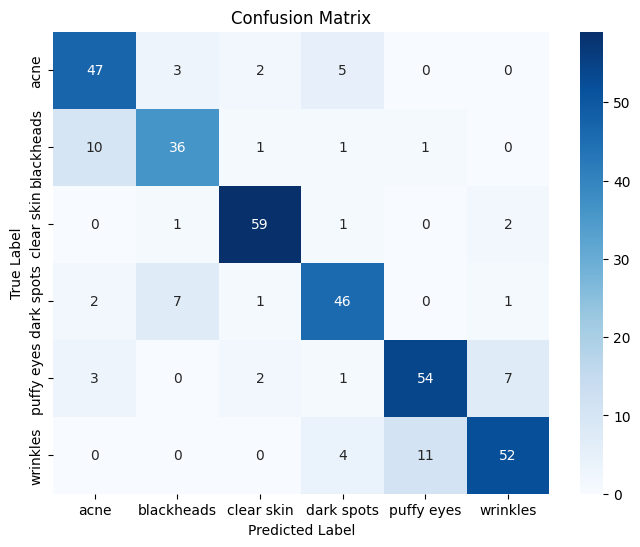

In [44]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()